# Import Library


In [1]:
 !pip install google-play-scraper

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Scrapping Dataset dan Loading Dataset



In [2]:
from google_play_scraper import reviews, Sort

scrapreview, _ = reviews(
    'com.duolingo',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=15000
)

app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df = app_reviews_df.drop_duplicates(subset='reviewId')
print(app_reviews_df.shape)

app_reviews_df.to_csv('ulasan_aplikasi.csv', index=False)

(15000, 11)


In [3]:
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9a6b01de-42de-48db-a4f1-a607216a288b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Setelah saya menggunakan duolingo selama 25 ha...,2,6,6.85.7,2026-06-30 12:21:12,None,None,6.85.7
1,7c53be56-253b-4cf2-a882-c14434a659ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu untuk aku belajar bahasa Inggr...,5,4,6.86.5,2026-07-07 05:50:08,None,None,6.86.5
2,8c0750b0-c4fb-4f13-b652-b64b75504cdb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"over all sih bagus, tapi tolong perbaiki bug s...",4,7,6.85.7,2026-06-28 05:05:22,None,None,6.85.7
3,e714f0e4-9fa6-4922-bd70-aaf5d9f6bba1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"duolingo se asik itu, aku belajar bahasa korea...",5,8,6.85.7,2026-06-27 03:18:44,None,None,6.85.7
4,182804fe-91fb-4152-9906-6b5cd583c1ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Maaf saya kurangi bintangnya. Sangat menyebalk...,1,8,6.85.7,2026-06-29 17:17:36,None,None,6.85.7


In [4]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              15000 non-null  object        
 1   userName              15000 non-null  object        
 2   userImage             15000 non-null  object        
 3   content               15000 non-null  object        
 4   score                 15000 non-null  int64         
 5   thumbsUpCount         15000 non-null  int64         
 6   reviewCreatedVersion  14669 non-null  object        
 7   at                    15000 non-null  datetime64[ns]
 8   replyContent          0 non-null      object        
 9   repliedAt             0 non-null      object        
 10  appVersion            14669 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 1.3+ MB


In [5]:
# Hapus kolom yang tidak terpakai / kosong total
clean_df = app_reviews_df.drop(columns=['replyContent', 'repliedAt'])

# Baru hapus baris dengan nilai NaN pada kolom sisanya (misal reviewCreatedVersion, appVersion)
clean_df = clean_df.dropna()

# Hapus baris duplikat
clean_df = clean_df.drop_duplicates()

print(clean_df.shape)
clean_df.info()

(14669, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 14669 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              14669 non-null  object        
 1   userName              14669 non-null  object        
 2   userImage             14669 non-null  object        
 3   content               14669 non-null  object        
 4   score                 14669 non-null  int64         
 5   thumbsUpCount         14669 non-null  int64         
 6   reviewCreatedVersion  14669 non-null  object        
 7   at                    14669 non-null  datetime64[ns]
 8   appVersion            14669 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 1.1+ MB


# Preprocessing Text

In [6]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','nya','na','sih','ku',"di","ya","gaa","loh","kah","woi","woii","woy"])

    # Kata negasi WAJIB dipertahankan, jangan sampai ikut terbuang
    negation_words = {'tidak', 'bukan', 'jangan', 'belum', 'tak', 'gak', 'ga', 'nggak', 'enggak'}
    listStopwords = listStopwords - negation_words

    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence


# ===== Slang words dictionary =====
slangwords = {
    "@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual",
    "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "gpp": "tidak apa apa",
    "gk": "tidak", "ngga": "tidak", "gaje": "tidak jelas", "bgus": "bagus",
    "tdk": "tidak", "dr": "dari", "yg": "yang", "utk": "untuk", "sm": "sama",
    "krn": "karena", "jg": "juga", "aja": "saja", "bs": "bisa", "udh": "sudah",
    "trs": "terus", "sy": "saya", "ga": "tidak", "tp": "tapi", "dgn": "dengan", "ngga": "tidak", "engga": "tidak",
    "skrg": "sekarang", "bkin": "bikin", "emg": "emang", "kek": "kayak", "gtu": "gitu",
    "klo": "kalau", "lg": "lagi", "lgsg": "langsung", "pdhl": "padahal", "jgn": "jangan",
    "knp": "kenapa", "dlu": "dulu", "sampe": "sampai", "pgn": "pengen"
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords.get(word.lower(), word) for word in words]
    fixed_text = ' '.join(fixed_words)
    return fixed_text


# ===== Terapkan pipeline preprocessing ke clean_df =====
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

# Hapus baris yang hasil akhirnya kosong (misalnya isinya cuma emoji/simbol yang semua terhapus)
clean_df = clean_df[clean_df['text_akhir'].str.strip() != '']
clean_df.reset_index(drop=True, inplace=True)

print(clean_df.shape)
clean_df[['content', 'text_akhir']].head()

(14669, 15)


,content,text_akhir
0,Setelah saya menggunakan duolingo selama 25 ha...,duolingo mengalami kendala speaking english ma...
1,sangat membantu untuk aku belajar bahasa Inggr...,membantu belajar bahasa inggris pelajarannya s...
2,"over all sih bagus, tapi tolong perbaiki bug s...",bagus tolong perbaiki bug selesai pelajaran tu...
3,"duolingo se asik itu, aku belajar bahasa korea...",duolingo asik belajar bahasa korea hangeulnya ...
4,Maaf saya kurangi bintangnya. Sangat menyebalk...,maaf kurangi bintangnya menyebalkan berkalikal...


In [7]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,9a6b01de-42de-48db-a4f1-a607216a288b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Setelah saya menggunakan duolingo selama 25 ha...,2,6,6.85.7,2026-06-30 12:21:12,6.85.7,Setelah saya menggunakan duolingo selama hari...,setelah saya menggunakan duolingo selama hari...,setelah saya menggunakan duolingo selama hari ...,"[setelah, saya, menggunakan, duolingo, selama,...","[duolingo, mengalami, kendala, speaking, engli...",duolingo mengalami kendala speaking english ma...
1,7c53be56-253b-4cf2-a882-c14434a659ba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu untuk aku belajar bahasa Inggr...,5,4,6.86.5,2026-07-07 05:50:08,6.86.5,sangat membantu untuk aku belajar bahasa Inggr...,sangat membantu untuk aku belajar bahasa inggr...,sangat membantu untuk aku belajar bahasa inggr...,"[sangat, membantu, untuk, aku, belajar, bahasa...","[membantu, belajar, bahasa, inggris, pelajaran...",membantu belajar bahasa inggris pelajarannya s...
2,8c0750b0-c4fb-4f13-b652-b64b75504cdb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"over all sih bagus, tapi tolong perbaiki bug s...",4,7,6.85.7,2026-06-28 05:05:22,6.85.7,over all sih bagus tapi tolong perbaiki bug se...,over all sih bagus tapi tolong perbaiki bug se...,over all sih bagus tapi tolong perbaiki bug se...,"[over, all, sih, bagus, tapi, tolong, perbaiki...","[bagus, tolong, perbaiki, bug, selesai, pelaja...",bagus tolong perbaiki bug selesai pelajaran tu...
3,e714f0e4-9fa6-4922-bd70-aaf5d9f6bba1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"duolingo se asik itu, aku belajar bahasa korea...",5,8,6.85.7,2026-06-27 03:18:44,6.85.7,duolingo se asik itu aku belajar bahasa korea ...,duolingo se asik itu aku belajar bahasa korea ...,duolingo se asik itu aku belajar bahasa korea ...,"[duolingo, se, asik, itu, aku, belajar, bahasa...","[duolingo, asik, belajar, bahasa, korea, hange...",duolingo asik belajar bahasa korea hangeulnya ...
4,182804fe-91fb-4152-9906-6b5cd583c1ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Maaf saya kurangi bintangnya. Sangat menyebalk...,1,8,6.85.7,2026-06-29 17:17:36,6.85.7,Maaf saya kurangi bintangnya Sangat menyebalka...,maaf saya kurangi bintangnya sangat menyebalka...,maaf saya kurangi bintangnya sangat menyebalka...,"[maaf, saya, kurangi, bintangnya, sangat, meny...","[maaf, kurangi, bintangnya, menyebalkan, berka...",maaf kurangi bintangnya menyebalkan berkalikal...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14664,174ee135-18a1-478a-a758-f007cf50d182,Bintan N.a,https://play-lh.googleusercontent.com/a/ACg8oc...,Bisa mengedukasi dan belajar lebih giat!! gak ...,5,1374,6.11.4,2024-12-24 04:50:09,6.11.4,Bisa mengedukasi dan belajar lebih giat gak ad...,bisa mengedukasi dan belajar lebih giat gak ad...,bisa mengedukasi dan belajar lebih giat gak ad...,"[bisa, mengedukasi, dan, belajar, lebih, giat,...","[mengedukasi, belajar, giat, gak, kekurangan, ...",mengedukasi belajar giat gak kekurangan gratis...
14665,28ccb8ea-d282-49b4-818f-736728f26cc1,Alecia Cia,https://play-lh.googleusercontent.com/a-/ALV-U...,"bagus banget ni apk, aku jadi terbantu dalam b...",5,2,5.59.5,2022-06-05 00:42:03,5.59.5,bagus banget ni apk aku jadi terbantu dalam be...,bagus banget ni apk aku jadi terbantu dalam be...,bagus banget ni apk aku jadi terbantu dalam be...,"[bagus, banget, ni, apk, aku, jadi, terbantu, ...","[bagus, banget, ni, apk, terbantu, belajar, ba...",bagus banget ni apk terbantu belajar bahasa in...
14666,d922f705-6141-4d9b-a213-b095f107c354,Rohmi Rohmulyati,https://play-lh.googleusercontent.com/a/ACg8oc...,ini membuat ku pintar bahasa spanyol,5,0,6.81.4,2026-06-07 05:05:56,6.81.4,ini membuat ku pintar bahasa spanyol,ini membuat ku pintar bahasa spanyol,ini memb

# Pelabelan

In [8]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

print(f"Jumlah kata dalam lexicon positif: {len(lexicon_positive)}")
print(f"Jumlah kata dalam lexicon negatif: {len(lexicon_negative)}")

Jumlah kata dalam lexicon positif: 3609
Jumlah kata dalam lexicon negatif: 6607


In [9]:
# ===== PATCH: bersihkan lexicon dari kata ambigu & kata topik netral =====

# Cari kata yang ada di KEDUA lexicon (skor saling bertentangan, contoh: 'bagus')
overlap_words = set(lexicon_positive.keys()) & set(lexicon_negative.keys())

# Kata topik/domain yang netral tapi salah terdeteksi sebagai sentimen negatif
domain_neutral_words = {'bahasa', 'aplikasi', 'duolingo', 'inggris', 'game', 'main', 'belajar'}

print(f"Sebelum dibersihkan -> positif: {len(lexicon_positive)} kata, negatif: {len(lexicon_negative)} kata")

# Overwrite langsung variabel lexicon_positive & lexicon_negative dengan versi bersih
lexicon_positive = {w: s for w, s in lexicon_positive.items()
                     if w not in overlap_words and w not in domain_neutral_words}
lexicon_negative = {w: s for w, s in lexicon_negative.items()
                     if w not in overlap_words and w not in domain_neutral_words}

print(f"Setelah dibersihkan  -> positif: {len(lexicon_positive)} kata, negatif: {len(lexicon_negative)} kata")

Sebelum dibersihkan -> positif: 3609 kata, negatif: 6607 kata
Setelah dibersihkan  -> positif: 2465 kata, negatif: 5463 kata


In [10]:
negation_words = {'tidak', 'bukan', 'jangan', 'belum', 'tak', 'gak', 'ga', 'nggak', 'enggak'}

def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for i, word in enumerate(text):
        word_score = 0
        if word in lexicon_positive:
            word_score = lexicon_positive[word]
        elif word in lexicon_negative:
            word_score = lexicon_negative[word]

        if word_score != 0:
            # Cek apakah kata sebelumnya (dalam jarak 1-2 kata) adalah kata negasi
            preceding = text[max(0, i-2):i]
            if any(w in negation_words for w in preceding):
                word_score = -word_score  # balik tandanya kalau didahului negasi

            score += word_score

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [11]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

print(clean_df['polarity'].value_counts())
print(clean_df['polarity'].value_counts(normalize=True) * 100)  # persentase tiap kelas

polarity
positive    5267
neutral     5177
negative    4225
Name: count, dtype: int64
polarity
positive    35.905651
neutral     35.292113
negative    28.802236
Name: proportion, dtype: float64


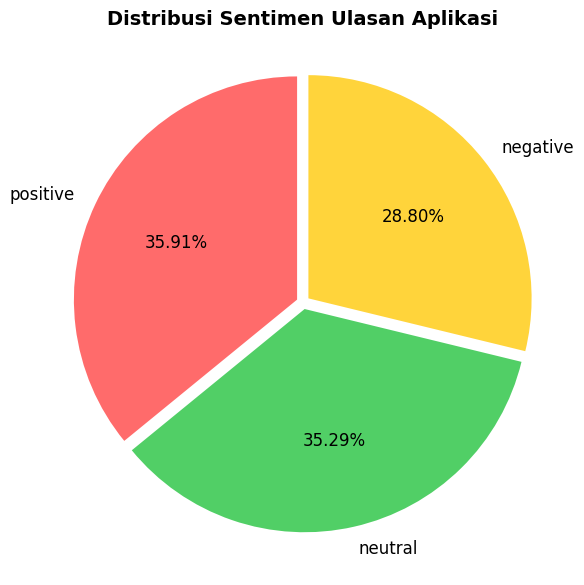

In [12]:
import matplotlib.pyplot as plt

# Hitung jumlah dan persentase tiap label sentimen
polarity_counts = clean_df['polarity'].value_counts()

# Buat pie chart
plt.figure(figsize=(6, 6))
colors = ['#ff6b6b', '#51cf66', '#ffd43b']  # merah=negative, hijau=positive, kuning=neutral (urutan sesuai data)

plt.pie(
    polarity_counts.values,
    labels=polarity_counts.index,
    autopct='%1.2f%%',       # tampilkan persentase 2 desimal
    startangle=90,
    colors=colors,
    explode=[0.03] * len(polarity_counts),  # sedikit terpisah biar rapi
    textprops={'fontsize': 12}
)

plt.title('Distribusi Sentimen Ulasan Aplikasi', fontsize=14, fontweight='bold')
plt.axis('equal')  # supaya pie chart berbentuk lingkaran sempurna
plt.tight_layout()
plt.show()

# Eksplorasi Label

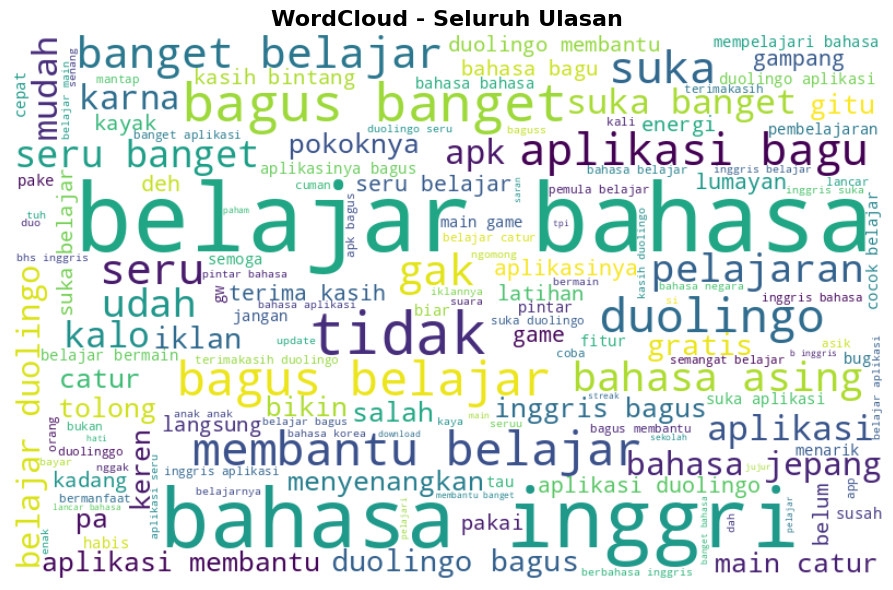

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ===== 1. WordCloud secara general (semua data) =====
all_text = ' '.join(clean_df['text_akhir'])

wc_all = WordCloud(
    width=800,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(all_text)

plt.figure(figsize=(10, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Seluruh Ulasan', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

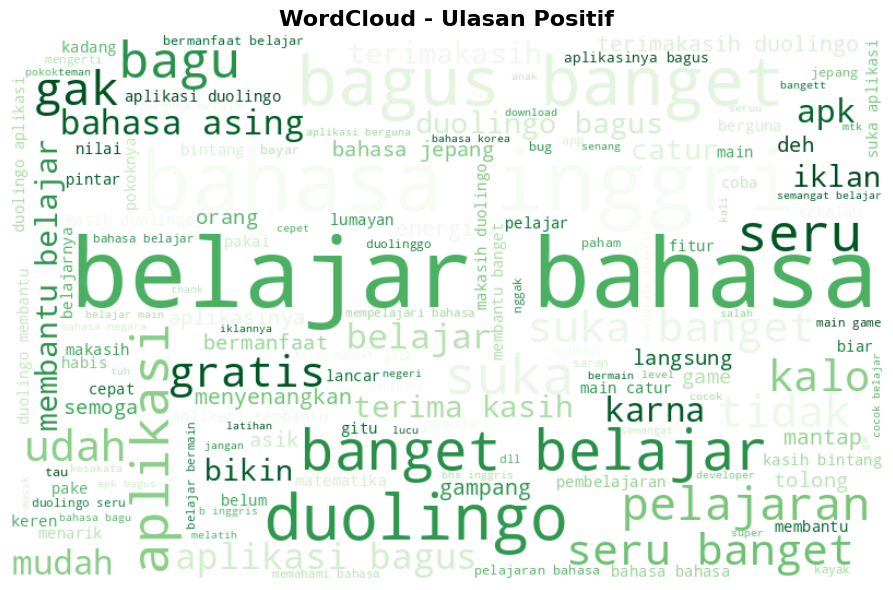

In [14]:
# ===== 2. WordCloud untuk data Positive =====
positive_text = ' '.join(clean_df[clean_df['polarity'] == 'positive']['text_akhir'])

wc_positive = WordCloud(
    width=800,
    height=500,
    background_color='white',
    colormap='Greens',
    max_words=150
).generate(positive_text)

plt.figure(figsize=(10, 6))
plt.imshow(wc_positive, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Ulasan Positif', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

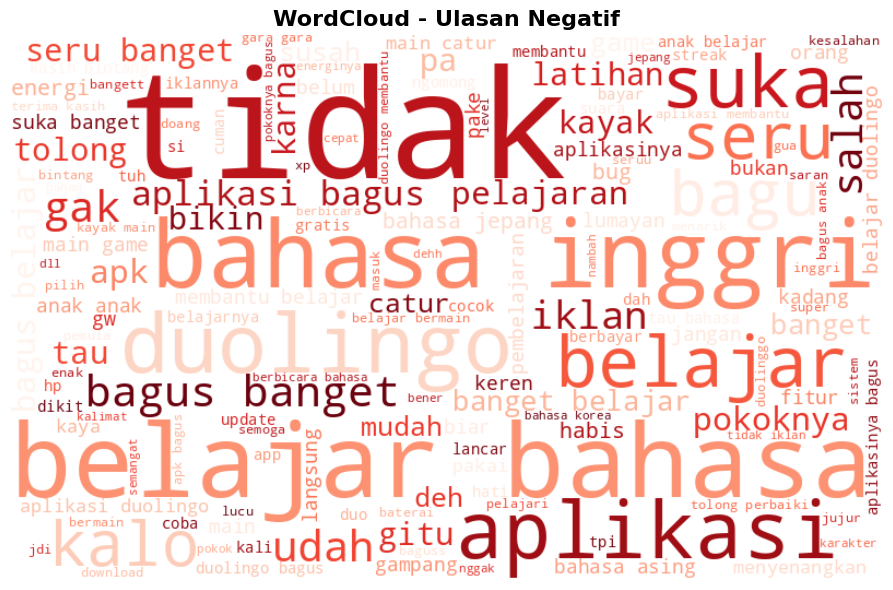

In [15]:
# ===== 3. WordCloud untuk data Negative =====
negative_text = ' '.join(clean_df[clean_df['polarity'] == 'negative']['text_akhir'])

wc_negative = WordCloud(
    width=800,
    height=500,
    background_color='white',
    colormap='Reds',
    max_words=150
).generate(negative_text)

plt.figure(figsize=(10, 6))
plt.imshow(wc_negative, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Ulasan Negatif', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

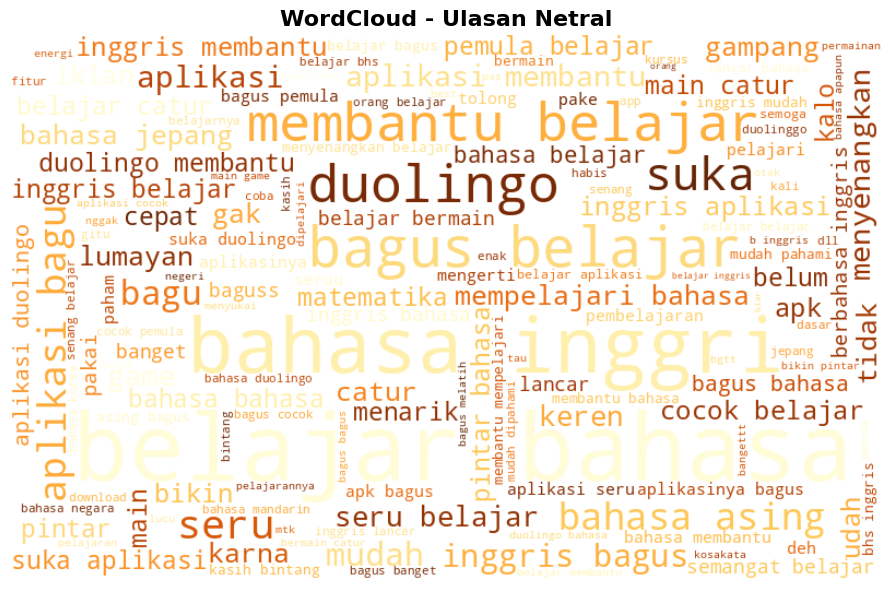

In [16]:
neutral_text = ' '.join(clean_df[clean_df['polarity'] == 'neutral']['text_akhir'])

wc_neutral = WordCloud(
    width=800,
    height=500,
    background_color='white',
    colormap='YlOrBr',
    max_words=150
).generate(neutral_text)

plt.figure(figsize=(10, 6))
plt.imshow(wc_neutral, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Ulasan Netral', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Data Splitting dan Ekstraksi Fitur dengan TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

# Pisahkan data menjadi fitur (teks ulasan) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

print(f"Total data: {len(X)}")
print(y.value_counts())

Total data: 14669
polarity
positive    5267
neutral     5177
negative    4225
Name: count, dtype: int64


In [18]:
# ===== Ekstraksi fitur dengan TF-IDF =====
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 1)
)
X_tfidf = tfidf.fit_transform(X)

print(f"Jumlah fitur (vocabulary) yang terbentuk: {len(tfidf.get_feature_names_out())}")
print(f"Shape matrix TF-IDF: {X_tfidf.shape}")

Jumlah fitur (vocabulary) yang terbentuk: 1969
Shape matrix TF-IDF: (14669, 1969)


In [19]:
# Cek sekilas fitur yang terbentuk (opsional, untuk sanity check)
features_df_preview = pd.DataFrame(
    X_tfidf[:5].toarray(),   # cuma preview 5 baris pertama, JANGAN convert semua baris
    columns=tfidf.get_feature_names_out()
)
features_df_preview

,acak,ad,adaa,adain,add,adek,adik,adil,admin,aga,...,zaman,𝐈𝐧𝐠𝐠𝐫𝐢𝐬,𝐚𝐤𝐮,𝐛𝐚𝐠𝐮𝐬,𝐛𝐚𝐡𝐚𝐬𝐚,𝐛𝐞𝐥𝐚𝐣𝐚𝐫,𝐛𝐢𝐬𝐚,𝐝𝐚𝐧,𝐦𝐞𝐦𝐛𝐚𝐧𝐭𝐮,𝚋𝚎𝚕𝚊𝚓𝚊𝚛
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# ===== Split data latih dan data uji =====
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # penting! supaya proporsi kelas tetap terjaga di train & test
)

print(f"Data latih : {X_train.shape[0]} baris")
print(f"Data uji   : {X_test.shape[0]} baris")
print()
print("Distribusi kelas di data latih:")
print(y_train.value_counts(normalize=True).round(3) * 100)
print()
print("Distribusi kelas di data uji:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Data latih : 11735 baris
Data uji   : 2934 baris

Distribusi kelas di data latih:
polarity
positive    35.9
neutral     35.3
negative    28.8
Name: proportion, dtype: float64

Distribusi kelas di data uji:
polarity
positive    35.9
neutral     35.3
negative    28.8
Name: proportion, dtype: float64


# Modelling

## Model SVM

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# ===== Training SVM =====
start_time = time.time()

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"Waktu training: {training_time:.2f} detik")

Waktu training: 5.49 detik


In [22]:
# ===== Prediksi & Evaluasi =====
y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)

accuracy_train_svm = accuracy_score(y_train, y_pred_train_svm)
accuracy_test_svm = accuracy_score(y_test, y_pred_test_svm)

print(f"SVM (TF-IDF, split 80/20)")
print(f"  Akurasi Train : {accuracy_train_svm:.4f} ({accuracy_train_svm*100:.2f}%)")
print(f"  Akurasi Test  : {accuracy_test_svm:.4f} ({accuracy_test_svm*100:.2f}%)")

SVM (TF-IDF, split 80/20)
  Akurasi Train : 0.9192 (91.92%)
  Akurasi Test  : 0.8821 (88.21%)


In [23]:
# ===== Classification Report & Confusion Matrix =====
print("Classification Report (data uji):")
print(classification_report(y_test, y_pred_test_svm))

Classification Report (data uji):
              precision    recall  f1-score   support

    negative       0.84      0.85      0.85       845
     neutral       0.89      0.94      0.92      1035
    positive       0.90      0.85      0.87      1054

    accuracy                           0.88      2934
   macro avg       0.88      0.88      0.88      2934
weighted avg       0.88      0.88      0.88      2934



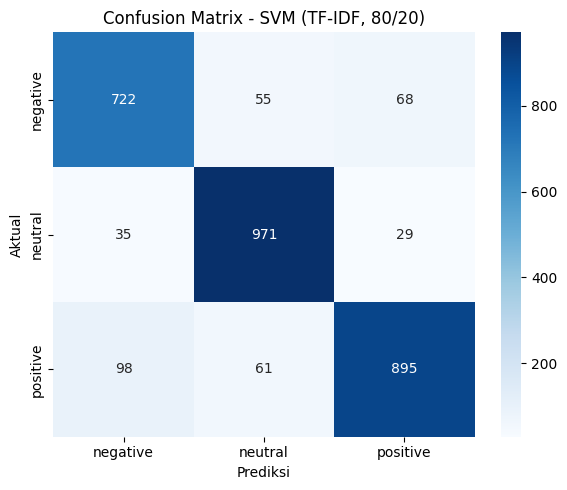

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test_svm, labels=svm_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - SVM (TF-IDF, 80/20)')
plt.tight_layout()
plt.show()

## Model LSTM

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# ===== Encode label jadi angka, lalu one-hot =====
le = LabelEncoder()
y_encoded = le.fit_transform(clean_df['polarity'])  # negative=0, neutral=1, positive=2
y_cat = to_categorical(y_encoded, num_classes=3)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [26]:
# ===== Tokenizer & padding untuk deep learning =====
max_features_dl = 5000   # ukuran vocabulary
max_len = 27          # panjang maksimum tiap ulasan (dalam token)

tokenizer_dl = Tokenizer(num_words=max_features_dl, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(clean_df['text_akhir'])

X_seq = tokenizer_dl.texts_to_sequences(clean_df['text_akhir'])
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Shape data setelah padding: {X_pad.shape}")

Shape data setelah padding: (14669, 27)


In [27]:
# 2. Split ULANG dengan X_pad yang baru
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Data latih: {X_train_dl.shape[0]}, Data uji: {X_test_dl.shape[0]}")

Data latih: 11735, Data uji: 2934


In [28]:
# ===== Hitung class_weight untuk menangani sedikit imbalance =====
classes = np.unique(y_encoded)
weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.157317554240631), np.int64(1): np.float64(0.9444981005730475), np.int64(2): np.float64(0.9283589646224922)}


In [29]:
# 3. Rebuild model dari NOL (jangan reuse model_lstm lama, karena Input shape-nya berubah)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_features_dl, output_dim=128),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 27, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,763 (2.65 MB)

 Trainable params: 693,763 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# 4. Training ulang (TANPA class_weight dulu, sesuai temuan kita sebelumnya)
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5394 - loss: 0.8975 - val_accuracy: 0.6503 - val_loss: 0.6914
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7005 - loss: 0.6556 - val_accuracy: 0.7573 - val_loss: 0.6199
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8104 - loss: 0.5140 - val_accuracy: 0.8323 - val_loss: 0.4861
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8689 - loss: 0.4086 - val_accuracy: 0.8494 - val_loss: 0.4409
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9029 - loss: 0.3217 - val_accuracy: 0.8640 - val_loss: 0.4184
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9232 - loss: 0.2683 - val_accuracy: 0.8742 - val_loss: 0.4093
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9332 - loss: 0.2285 - val_accuracy: 0.8746 - val_loss: 0.4089
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9430 - loss: 0.1952 - val_acc

In [31]:
# ===== Evaluasi =====
train_acc_lstm = model_lstm.evaluate(X_train_dl, y_train_dl, verbose=0)[1]
test_acc_lstm = model_lstm.evaluate(X_test_dl, y_test_dl, verbose=0)[1]

print(f"Skema 2 (LSTM + Tokenizer/Embedding, split 80/20)")
print(f"  Akurasi Train: {train_acc_lstm:.4f} ({train_acc_lstm*100:.2f}%)")
print(f"  Akurasi Test : {test_acc_lstm:.4f} ({test_acc_lstm*100:.2f}%)")

Skema 2 (LSTM + Tokenizer/Embedding, split 80/20)
  Akurasi Train: 0.9548 (95.48%)
  Akurasi Test : 0.8824 (88.24%)


## Model Bidirectional LSTM

In [32]:
!pip install gensim -q
from gensim.models import Word2Vec

In [33]:
# ===== Latih Word2Vec dari corpus ulasan =====
tokenized_corpus = clean_df['text_stopword'].tolist()  # list of list token, hasil preprocessing

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=128,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

print(f"Jumlah kata dalam vocabulary Word2Vec: {len(w2v_model.wv)}")

Jumlah kata dalam vocabulary Word2Vec: 4790


In [34]:
# ===== Bangun embedding matrix dari Word2Vec, dipetakan ke index Tokenizer =====
embedding_dim = 128
word_index = tokenizer_dl.word_index  # tokenizer yang sudah kamu fit sebelumnya (max_features_dl=5000)

embedding_matrix = np.zeros((max_features_dl, embedding_dim))
found = 0
for word, i in word_index.items():
    if i < max_features_dl and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
        found += 1

print(f"Kata yang berhasil dipetakan ke embedding Word2Vec: {found} dari {max_features_dl}")

Kata yang berhasil dipetakan ke embedding Word2Vec: 4790 dari 5000


In [35]:
# ===== Split 70/30 (variasi split beda dari Skema 1 & 2) =====
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_pad, y_cat, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Data latih: {X_train3.shape[0]}, Data uji: {X_test3.shape[0]}")

Data latih: 10268, Data uji: 4401


In [36]:
# ===== Bangun model Bidirectional LSTM dengan embedding Word2Vec sebagai bobot awal =====
from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=max_features_dl,
        output_dim=embedding_dim,
        weights=[embedding_matrix],   # inisialisasi dari Word2Vec, bukan random
        trainable=True                 # tetap boleh di-fine-tune saat training
    ),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 27, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,267 (2.85 MB)

 Trainable params: 747,267 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ===== Training =====
early_stop3 = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history_bilstm = model_bilstm.fit(
    X_train3, y_train3,
    validation_data=(X_test3, y_test3),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop3],
    verbose=1
)

Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step - accuracy: 0.5511 - loss: 0.9136 - val_accuracy: 0.6246 - val_loss: 0.8056
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.7157 - loss: 0.6681 - val_accuracy: 0.8321 - val_loss: 0.4494
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.8656 - loss: 0.3903 - val_accuracy: 0.8641 - val_loss: 0.3842
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9123 - loss: 0.2675 - val_accuracy: 0.8866 - val_loss: 0.3543
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.9388 - loss: 0.1954 - val_accuracy: 0.8805 - val_loss: 0.4086
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9519 - loss: 0.1573 - val_accuracy: 0.8759 - val_loss: 0.4893
Epoch 7/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9579 - loss: 0.1376 - val_accuracy: 0.8732 - val_loss: 0.5218


In [38]:
# ===== Evaluasi =====
train_acc_bilstm = model_bilstm.evaluate(X_train3, y_train3, verbose=0)[1]
test_acc_bilstm = model_bilstm.evaluate(X_test3, y_test3, verbose=0)[1]

print(f"Skema 3 (Bi-LSTM + Word2Vec, split 70/30)")
print(f"  Akurasi Train: {train_acc_bilstm:.4f} ({train_acc_bilstm*100:.2f}%)")
print(f"  Akurasi Test : {test_acc_bilstm:.4f} ({test_acc_bilstm*100:.2f}%)")

Skema 3 (Bi-LSTM + Word2Vec, split 70/30)
  Akurasi Train: 0.9426 (94.26%)
  Akurasi Test : 0.8866 (88.66%)


# Testing

In [39]:
def predict_sentiment(text, model, tokenizer, label_encoder, max_len=27):
    # Preprocessing — HARUS sama persis dengan pipeline training
    t = cleaningText(text)
    t = casefoldingText(t)
    t = fix_slangwords(t)
    tokens = tokenizingText(t)
    tokens = filteringText(tokens)
    sentence = toSentence(tokens)

    seq = tokenizer.texts_to_sequences([sentence])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    pred_prob = model.predict(pad, verbose=0)
    pred_class_idx = np.argmax(pred_prob, axis=1)[0]
    pred_label = label_encoder.inverse_transform([pred_class_idx])[0]

    return pred_label, pred_prob[0]

In [40]:
test_sentences_final = [
    "Sering error dan banyak iklan, sangat mengganggu, tidak recommended",
    "Parah banget aplikasinya, sering crash dan bikin kesel",
    "Keren, fiturnya lengkap dan sangat memuaskan, recommended banget",
    "Gak nyesel install aplikasi ini, sangat worth it",
    "Aplikasi ini oke-oke saja, tidak terlalu istimewa tapi juga tidak buruk"
]

print("=" * 70)
for sentence in test_sentences_final:
    label, prob = predict_sentiment(sentence, model_lstm, tokenizer_dl, le)
    print(f"Teks     : {sentence}")
    print(f"Prediksi : {label}")
    print(f"Probabilitas: negative={prob[0]:.3f}, neutral={prob[1]:.3f}, positive={prob[2]:.3f}")
    print("-" * 70)

Teks     : Sering error dan banyak iklan, sangat mengganggu, tidak recommended
Prediksi : negative
Probabilitas: negative=0.983, neutral=0.008, positive=0.008
----------------------------------------------------------------------
Teks     : Parah banget aplikasinya, sering crash dan bikin kesel
Prediksi : negative
Probabilitas: negative=0.983, neutral=0.009, positive=0.008
----------------------------------------------------------------------
Teks     : Keren, fiturnya lengkap dan sangat memuaskan, recommended banget
Prediksi : positive
Probabilitas: negative=0.001, neutral=0.001, positive=0.998
----------------------------------------------------------------------
Teks     : Gak nyesel install aplikasi ini, sangat worth it
Prediksi : positive
Probabilitas: negative=0.099, neutral=0.441, positive=0.460
----------------------------------------------------------------------
Teks     : Aplikasi ini oke-oke saja, tidak terlalu istimewa tapi juga tidak buruk
Prediksi : negative
Probabilitas